In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import sys
sys.path.append("..")

In [5]:
import datetime
import os
import pickle
import random
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from ignite.engine import Engine, Events
from ignite.handlers import EarlyStopping
from ignite.handlers.param_scheduler import create_lr_scheduler_with_warmup
from ignite.metrics import Accuracy, Loss
from ignite.utils import convert_tensor
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau
from torch.utils.data import DataLoader, Subset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from clinic_datasets import CleanClinicDataset
from metrics import SklearnClassificationReport
from ignite.metrics.confusion_matrix import ConfusionMatrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from utils import *
from model import BertGAT, BertGCN
import torch.utils.data as Data
import dgl


from captum.attr import LayerIntegratedGradients, TokenReferenceBase, visualization
import shap

import dgl
import dgl.nn as dglnn
import torch
import torch.nn.functional as F
from captum.attr import IntegratedGradients
from functools import partial
from itertools import chain
from collections import defaultdict

Using backend: pytorch


In [6]:
MODELPATH = "deepset/gbert-base"
LEARNINGRATE = 5e-5
NEPOCHS = 50
BATCHSIZE = 8
ACCUSTEPS = 8

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODELPATH)
SAVENAME = Path(MODELPATH).stem

dataset_file = Path("..")/ "data" / "medindcls_bert.json"
if not dataset_file.exists():
    print("Creating dataset")
    dataset = CleanClinicDataset(tokenizer=tokenizer, clean=False)
    with open(dataset_file, "wb") as f:
        print(f"Saving dataset under {dataset_file}")
        pickle.dump(dataset, f)
else:
    print(f"Loading dataset from: {dataset_file}")
    with open(dataset_file, "rb") as f:
        dataset = pickle.load(f)

SAVEPATH = Path(f"models/finetuned/{SAVENAME}_{dataset}_best.pt")

idx = np.arange(len(dataset))
random.shuffle(idx)

train_idx, val_idx, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

test_dataset = Subset(dataset, test_idx)

Loading dataset from: ../data/medindcls_bert.json


In [8]:
train_idx, val_idx, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

GCNPATH = Path(f"../models/gcn/{SAVENAME}_{dataset}_best.pt")

DATASET = "../data/ind.med_indication_all_RF_diag"

device = "cpu"

adj, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, _, _ = load_corpus(DATASET)

nb_node = features.shape[0]
nb_train, nb_val, nb_test = train_mask.sum(), val_mask.sum(), test_mask.sum()
nb_word = nb_node - nb_train - nb_val - nb_test
nb_class = y_train.shape[1]

# if gcn_model == "gcn":
gcn = BertGCN(
    nb_class=nb_class,
    pretrained_model="deepset/gbert-base",
    mix_factor=0.4,
    gcn_layers=2,
    n_hidden=200,
    dropout=0.5,
)

gcn = gcn.eval()

y = y_train + y_test + y_val
y_train = y_train.argmax(axis=1)
y = y.argmax(axis=1)

# document mask used for update feature
doc_mask = train_mask + val_mask + test_mask

tokenizer = AutoTokenizer.from_pretrained(MODELPATH)

# logging.info(f"Len idx: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

input_ids = torch.cat(
    [
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[train_idx]])),
        torch.zeros((nb_word, tokenizer.model_max_length), dtype=torch.long),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[val_idx]])),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[test_idx]])),
    ]
)    

adj_norm = normalize_adj(adj + sp.eye(adj.shape[0]))

train_idx_dataset = Data.TensorDataset(torch.arange(0, nb_train, dtype=torch.long))
val_idx_dataset = Data.TensorDataset(
    torch.arange(nb_train + nb_word, nb_train + nb_word + nb_val, dtype=torch.long)
)
test_idx_dataset = Data.TensorDataset(torch.arange(nb_node - nb_test, nb_node, dtype=torch.long))

idx_loader_train = Data.DataLoader(train_idx_dataset, batch_size=BATCHSIZE)
idx_loader_val = Data.DataLoader(val_idx_dataset, batch_size=BATCHSIZE)
idx_loader_test = Data.DataLoader(test_idx_dataset, batch_size=BATCHSIZE)


graph = dgl.from_scipy(adj_norm.astype("float32"), eweight_name="edge_weight")
graph.ndata["input_ids"] = input_ids
graph.ndata["label"], graph.ndata["train"], graph.ndata["val"], graph.ndata["test"] = (
    torch.LongTensor(y),
    torch.FloatTensor(train_mask),
    torch.FloatTensor(val_mask),
    torch.FloatTensor(test_mask),
)
graph.ndata["label_train"] = torch.LongTensor(y_train)
graph.ndata["cls_feats"] = torch.zeros((nb_node, gcn.feat_dim))

def update_feature():
    global graph, gcn
    dataloader = Data.DataLoader(Data.TensorDataset(graph.ndata["input_ids"][doc_mask]), batch_size=64)
    with torch.no_grad():
        gcn = gcn.to(device)
        gcn.eval()
        cls_list = []
        print("Udating features...")
        for batch in dataloader:
            input_ids = [x.to(device) for x in batch][0]
            output = gcn.bert_model(input_ids=input_ids)[0][:, 0]
            cls_list.append(output.cpu())
        cls_feat = torch.cat(cls_list, axis=0)
    graph = graph.to("cpu")
    graph.ndata["cls_feats"][doc_mask] = cls_feat
    
print(
    f"Loading best gcn model from {GCNPATH} saved on {datetime.datetime.fromtimestamp(GCNPATH.stat().st_ctime)}"
)
gcn.load_state_dict(torch.load(GCNPATH, map_location="cpu"))
update_feature()

27996
Loading best gcn model from ../models/gcn/gbert-base_med_indication_all_RF_diag_best.pt saved on 2022-11-04 15:53:12
Udating features...


In [16]:
def ig_forward(doc_feats, graph, target_id2):
    return gcn.explain_forward(doc_feats, graph, target_id2, doc_mask)

doc_feats = graph.ndata["cls_feats"][doc_mask].requires_grad_()

In [17]:
attr_dict = defaultdict(lambda: defaultdict(list))

for target_id1 in range(1):
    target_id2 = test_mask.nonzero()[0][target_id1]
    target_label = graph.ndata["label"][target_id2].item()
    target_cls = dataset.LE.classes_[target_label]
    ig = IntegratedGradients(partial(ig_forward, graph=graph, target_id2=target_id2))
    attr, delta = ig.attribute(doc_feats, target=target_label, internal_batch_size=graph.num_nodes(), n_steps=5, return_convergence_delta=True)
    attr = attr.sum(dim=-1)
    attr = attr / torch.norm(attr)
    attr = attr.cpu().detach().numpy()
    for id1 in np.argpartition(attr, -10)[-10:][::-1]:
        id2 = doc_mask.nonzero()[0][id1]
        label = graph.ndata["label"][id2].item()
        tgt_cls = dataset.LE.classes_[label]
        attr_dict[target_id2]["rel_doc_ids"].append(id2)
        attr_dict[target_id2]["rel_doc_labels"].append(tgt_cls)
print(attr_dict)

User provided device_type of 'cuda', but CUDA is not available. Disabling


defaultdict(<function <lambda> at 0x7f556f21aea0>, {27456: defaultdict(<class 'list'>, {'rel_doc_ids': [27995, 897, 27456, 896, 899, 903, 901, 902, 900, 898], 'rel_doc_labels': ['Blutdrucksenker_Blutdruck', 'Cholesterinsenker_beides', 'Blutdrucksenker_beides', 'DM_nur Tabletten', 'Cholesterinsenker_beides', 'Blutdrucksenker_beides', 'Blutdrucksenker_beides', 'DM_Insulin und Tabletten', 'Blutdrucksenker_unklar', 'Cholesterinsenker_beides']})})


In [19]:
target_id1 = 2
target_id2 = test_mask.nonzero()[0][target_id1]

target_label = graph.ndata["label"][target_id2].item()
target_cls = dataset.LE.classes_[target_label]

ig = IntegratedGradients(partial(ig_forward, graph=graph, target_id2=target_id2))
attr, delta = ig.attribute(doc_feats, target=target_label, internal_batch_size=graph.num_nodes(), n_steps=5, return_convergence_delta=True)
attr = attr.sum(dim=-1).squeeze()
attr = attr / torch.norm(attr)
attr = attr.cpu().detach().numpy()
attr.shape

(2699,)

In [20]:
pred = gcn(graph, [target_id2]) 
pred_label = torch.argmax(pred).item()
pred_cls = dataset.LE.classes_[pred_label]
prob = torch.max(torch.softmax(pred, dim=-1)).item()

train_val = train_mask.sum() + val_mask.sum()
test = test_mask.nonzero()[0][0]
text = list(map(str, (chain(range(train_val), range(test, len(doc_mask))))))
print(len(text))

vis = visualization.VisualizationDataRecord(attr, prob,
                    pred_cls, # predicted
                    target_cls, # true
                    target_cls, # attributed
                    attr.sum(), text, delta)
_ = visualization.visualize_text([vis])

2699


In [165]:
for id1 in np.argpartition(attr, -10)[-10:][::-1]:
    id2 = doc_mask.nonzero()[0][id1]
    label = graph.ndata["label"][id2].item()
    tgt_cls = dataset.LE.classes_[label]
    print(tgt_cls, id1, id2)

Blutdrucksenker_Blutdruck 2161 27458
Blutdrucksenker_Blutdruck 1016 1016
Blutdrucksenker_Blutdruck 1048 1048
Blutdrucksenker_Blutdruck 88 88
Blutdrucksenker_Blutdruck 1728 1728
Blutdrucksenker_Blutdruck 1725 1725
Blutdrucksenker_Blutdruck 428 428
Blutdrucksenker_Blutdruck 1211 1211
Blutdrucksenker_Blutdruck 20 20
Blutdrucksenker_Blutdruck 1053 1053


In [22]:
def zero_masker(node_mask, node_ids):
    return node_mask.reshape(1, len(node_mask))

def shap_forward(node_mask, graph, target_id2, doc_feats):
    graph = graph.to(device)
    doc_feats = [doc_feats.detach() * m[:, None] for m in node_mask]
    doc_feats = torch.cat(doc_feats, dim=0).float()
    doc_feats = doc_feats.to(device)
    outputs = gcn.explain_forward(doc_feats, graph, target_id2, doc_mask)
    #outputs = torch.softmax(outputs, dim=-1)
    return outputs.detach().cpu().numpy()

explainer = shap.explainers.Permutation(
    partial(shap_forward, graph=graph, target_id2=target_id2, doc_feats=doc_feats), zero_masker, max_evals=5399
)

#shap_values = explainer(np.array([np.ones(doc_feats.size(0))]))
node_ids = np.array([list(map(str, (chain(range(train_val), range(test, len(doc_mask))))))], dtype=str)
shap_values = explainer(node_ids)

Permutation explainer: 2it [54:00, 3240.54s/it]             


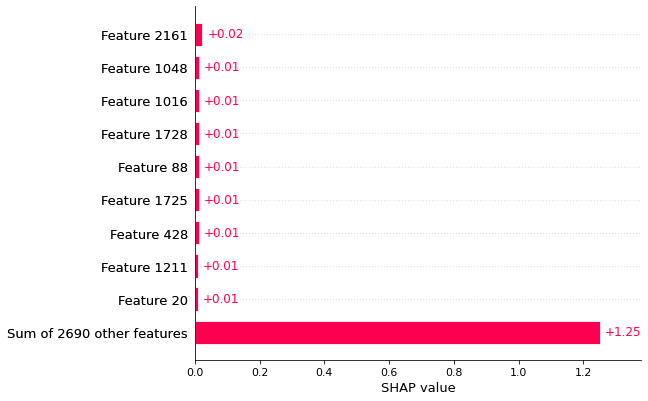

In [23]:
shap.plots.bar(shap_values[0, :, target_label], order=shap.Explanation.argsort.flip)

In [24]:
for id1 in np.argpartition(shap_values, -10)[-10:][::-1]:
    id2 = doc_mask.nonzero()[0][id1]
    label = graph.ndata["label"][id2].item()
    tgt_cls = dataset.LE.classes_[label]
    print(tgt_cls, id1, id2)

TypeError: '<' not supported between instances of 'Explanation' and 'Explanation'

In [112]:
test_mask.sum()

540